In [1]:
from collections import defaultdict
from itertools import combinations

In [2]:
def generate_candidates(dataset, k):
    candidates = defaultdict(int)

    for sequence in dataset:
        for candidate in combinations(sequence, k):
            candidates[candidate] += 1

    return candidates

In [3]:
def gsp(dataset, min_support):
    frequent_patterns = {}
    k = 1

    while True:
        candidates = generate_candidates(dataset, k)

        frequent = {
            pattern: support
            for pattern, support in candidates.items()
            if support >= min_support
        }

        if not frequent:
            break

        frequent_patterns.update(frequent)
        k += 1

    return frequent_patterns

In [4]:
top_wear_data = [
    ["blouse", "t-shirt", "tank_top"],
    ["hoodie", "sweater", "top"],
    ["hoodie"],
    ["hoodie", "sweater"]
]

bottom_wear_data = [
    ["jeans", "trousers", "shorts"],
    ["leggings", "skirt", "chinos"]
]

party_wear_data = [
    ["cocktail_dress", "evening_gown", "blazer"],
    ["party_dress", "formal_dress", "suit"],
    ["party_dress", "formal_dress", "suit"],
    ["party_dress", "formal_dress", "suit"],
    ["party_dress", "formal_dress", "suit"],
    ["party_dress"],
    ["party_dress"]
]

In [5]:
min_support = 2

In [6]:
top_wear_result = gsp(top_wear_data, min_support)

bottom_wear_result = gsp(bottom_wear_data, min_support)

party_wear_result = gsp(party_wear_data, min_support)

In [7]:
print("Frequent Sequential Patterns - Top Wear:")

if top_wear_result:
    for pattern, support in top_wear_result.items():
        print(f"Pattern: {pattern}, Support: {support}")
else:
    print("No frequent sequential patterns found in Top Wear.")


print("\nFrequent Sequential Patterns - Bottom Wear:")

if bottom_wear_result:
    for pattern, support in bottom_wear_result.items():
        print(f"Pattern: {pattern}, Support: {support}")
else:
    print("No frequent sequential patterns found in Bottom Wear.")


print("\nFrequent Sequential Patterns - Party Wear:")

if party_wear_result:
    for pattern, support in party_wear_result.items():
        print(f"Pattern: {pattern}, Support: {support}")
else:
    print("No frequent sequential patterns found in Party Wear.")

Frequent Sequential Patterns - Top Wear:
Pattern: ('hoodie',), Support: 3
Pattern: ('sweater',), Support: 2
Pattern: ('hoodie', 'sweater'), Support: 2

Frequent Sequential Patterns - Bottom Wear:
No frequent sequential patterns found in Bottom Wear.

Frequent Sequential Patterns - Party Wear:
Pattern: ('party_dress',), Support: 6
Pattern: ('formal_dress',), Support: 4
Pattern: ('suit',), Support: 4
Pattern: ('party_dress', 'formal_dress'), Support: 4
Pattern: ('party_dress', 'suit'), Support: 4
Pattern: ('formal_dress', 'suit'), Support: 4
Pattern: ('party_dress', 'formal_dress', 'suit'), Support: 4


In [8]:
import matplotlib.pyplot as plt

def visualize_patterns_line(result, category):
    if result:
        patterns = list(result.keys())
        support = list(result.values())

        plt.figure(figsize=(10, 6))

        plt.plot(
            [str(pattern) for pattern in patterns],
            support,
            marker='o',
            linestyle='-'
        )

        plt.xlabel("Patterns")
        plt.ylabel("Support Count")
        plt.title(f"Frequent Sequential Patterns - {category}")

        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    else:
        print(f"No frequent sequential patterns found in {category}.")

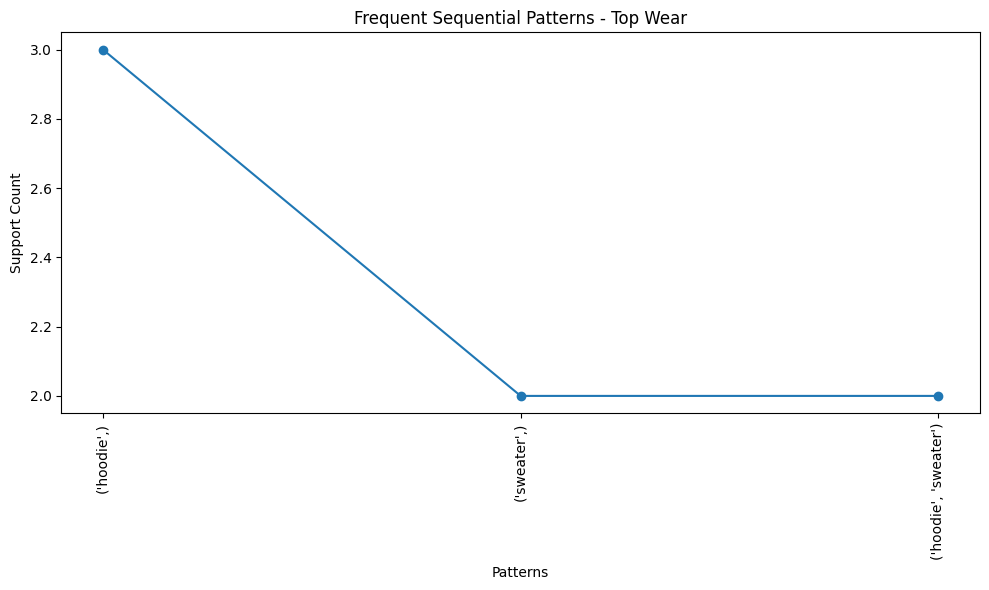

No frequent sequential patterns found in Bottom Wear.


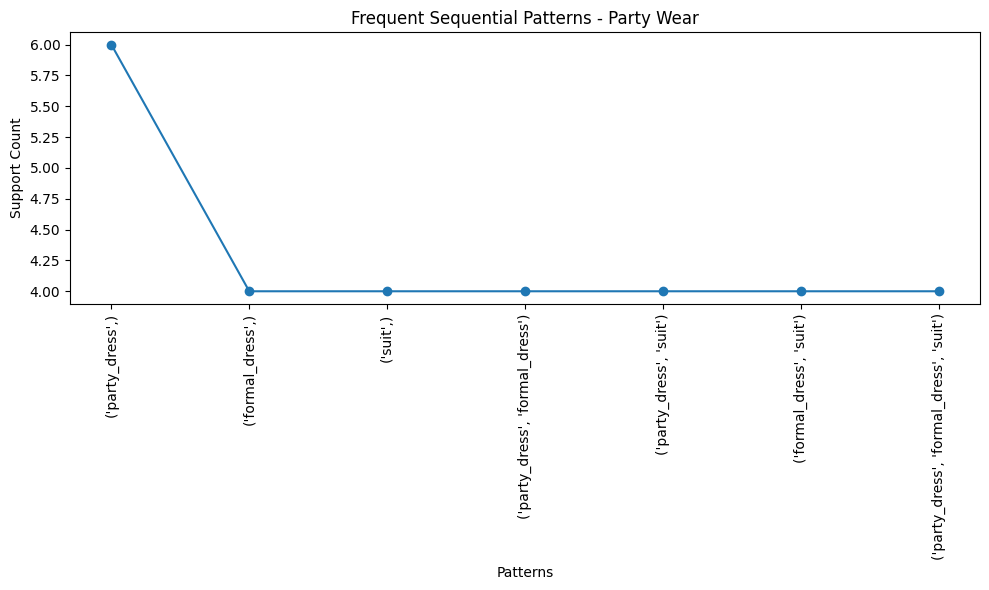

In [9]:
visualize_patterns_line(top_wear_result, "Top Wear")

visualize_patterns_line(bottom_wear_result, "Bottom Wear")

visualize_patterns_line(party_wear_result, "Party Wear")